<center><h1>Madhani_Ishan_FinalProject</h1></center>

Name: Ishan Madhani
<br>
Github Username: imm0410
<br>
USC ID: 7544567833

## 1. Transfer Learning for Image Classification1

### (a) In this problem, we are trying to build a classifier that distinguishes images of nine types of waste.

In [63]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import os
import cv2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

### (b) Data Exploration and Pre-processing

#### i. Images are numbered in each folder. Select the first 80% of the images in each folder as your training set and the rest as the test set. You can encode your classes using one-hot encoding.

#### ii. In case all the images do not have the same size, zero-pad or resize the images in your dataset. This can be done using various tools, including OpenCV.

In [64]:
# Set the dataset path
data_dir = "../data/RealWaste"
image_size = (160, 160)

X, y = [], []
# Only include directories (class folders)
class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
label_map = {cls: idx for idx, cls in enumerate(class_names)}

for cls in class_names:
    cls_path = os.path.join(data_dir, cls)
    image_files = sorted(os.listdir(cls_path))
    
    for file_name in image_files:
        img_path = os.path.join(cls_path, file_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, image_size)
            X.append(img)
            y.append(label_map[cls])

X = np.array(X, dtype=np.uint8)
y = np.array(y)
print(f"Loaded {len(X)} images of shape {X.shape[1:]}")

Loaded 4752 images of shape (160, 160, 3)


In [65]:
# One-hot encode labels
y_cat = to_categorical(y, num_classes=len(class_names))

print("Input shape:", X.shape)
print("One-hot label shape:", y_cat.shape)

Input shape: (4752, 160, 160, 3)
One-hot label shape: (4752, 9)


In [66]:
from sklearn.model_selection import train_test_split

# One-hot encode labels
y_cat = to_categorical(y, num_classes=len(class_names))

# Global stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=42
)

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Train set shape: (3801, 160, 160, 3)
Test set shape: (951, 160, 160, 3)


### (c) Transfer Learning3

#### i. When dealing with classification of relatively small image datasets, deep networks may not perform very well because of not having enough data to train them. In such cases, one usually uses transfer learning, which uses deep learning models that are trained on very large datasets such as ImageNet as feature extractors. The idea is that such deep networks have learned to extract meaningful features from an image using their layers, and those fea- tures can be used in learning other tasks. In order to do that, usually the last layer or the last few layers of the pre-trained network are removed, and the response of the layer before the removed layers to the images in the new dataset is used as a feature vector to train one more multiple replacement lay- ers. In this project, you will use pre-trained models ResNet50, ResNet100, EfficientNetB0, and VGG16. For those pre-trained networks, you will only train the last fully connected layer, and will freeze all layers before them (i.e. we do not change their parameters during training) and use the outputs of the penultimate layer in the original pre-trained model as the features extracted from each image.

#### ii. To perform empirical regularization, crop, randomly zoom, rotate, flip, contrast, and translate images in your training set for image augmentation. You can use various tools to do this, including OpenCV.

#### iii. Use ReLU activation functions in the last layer and a softmax layer, along with L2 regularization, batch normalization, and a dropout rate of 20% as well as ADAM optimizer. Use multinomial cross entropy loss. You can try any batch size, but a batch size of 5 seems reasonable.

#### iv. Train the networks for at least 50 epochs (preferably 100 epochs) and perform early stopping using the validation set. Use a randomly selected subset of 20% of each class as the validation set. Keep the network parameters that have the lowest validation error. Plot the training and validation errors vs. epochs.

#### v. Report training, validation, and test Precision, Recall, AUC, and F1 score for those models. Is there a model that clearly outperforms others? Remember that this is a multi-class classification problem.

In [67]:
# Augmentation for training set
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 20% validation from training
)

train_generator = datagen.flow(X_train, y_train, batch_size=5, subset='training')
val_generator = datagen.flow(X_train, y_train, batch_size=5, subset='validation')

In [68]:
def build_transfer_model(base_model_fn, input_shape=(160, 160, 3), num_classes=9):
    base_model = base_model_fn(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False  # Freeze all layers
    
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [69]:
def train_model(model, name):
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=50,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Plot training vs validation loss
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{name} - Loss Curve")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    
    return model

Epoch 1/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 80s 127ms/step - accuracy: 0.4543 - loss: 4.1111 - val_accuracy: 0.6776 - val_loss: 2.6974
Epoch 2/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 81s 134ms/step - accuracy: 0.6269 - loss: 2.6459 - val_accuracy: 0.7053 - val_loss: 2.1026
Epoch 3/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 84s 138ms/step - accuracy: 0.6578 - loss: 2.0291 - val_accuracy: 0.7211 - val_loss: 1.7476
Epoch 4/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 84s 137ms/step - accuracy: 0.6785 - loss: 1.7785 - val_accuracy: 0.6855 - val_loss: 1.7133
Epoch 5/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 87s 143ms/step - accuracy: 0.6676 - loss: 1.7644 - val_accuracy: 0.6868 - val_loss: 1.6609
Epoch 6/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 84s 138ms/step - accuracy: 0.6846 - loss: 1.6639 - val_accuracy: 0.7039 - val_loss: 1.6105
Epoch 7/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 85s 140ms/step - accuracy: 0.7021 - loss: 1.6194 - val_accuracy: 0.6763 - val_loss: 1.6243
Epoch 8/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 85s 139ms/step - accuracy: 0.6833 - loss: 1

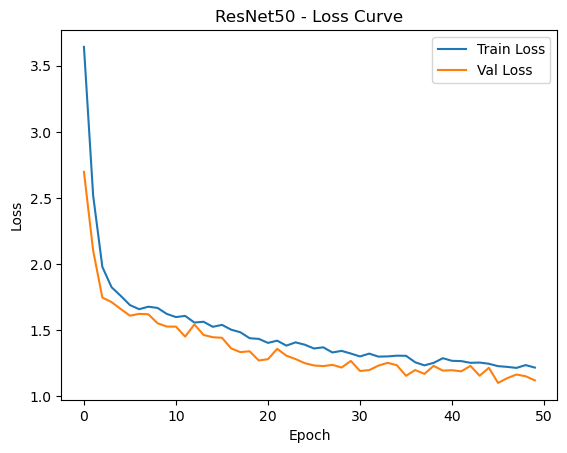

In [70]:
# Train ResNet50
resnet50_model = build_transfer_model(ResNet50)
resnet50_model = train_model(resnet50_model, "ResNet50")

Epoch 1/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 146s 234ms/step - accuracy: 0.4360 - loss: 4.1698 - val_accuracy: 0.6803 - val_loss: 2.7146
Epoch 2/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 148s 243ms/step - accuracy: 0.6564 - loss: 2.5736 - val_accuracy: 0.6776 - val_loss: 2.0452
Epoch 3/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 155s 255ms/step - accuracy: 0.6619 - loss: 1.9890 - val_accuracy: 0.6882 - val_loss: 1.7500
Epoch 4/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 154s 252ms/step - accuracy: 0.6639 - loss: 1.8078 - val_accuracy: 0.7066 - val_loss: 1.7118
Epoch 5/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 156s 257ms/step - accuracy: 0.6526 - loss: 1.7591 - val_accuracy: 0.7158 - val_loss: 1.5759
Epoch 6/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 158s 260ms/step - accuracy: 0.6694 - loss: 1.6958 - val_accuracy: 0.6842 - val_loss: 1.6501
Epoch 7/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 160s 262ms/step - accuracy: 0.6848 - loss: 1.6478 - val_accuracy: 0.7013 - val_loss: 1.5435
Epoch 8/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 157s 258ms/step - accuracy: 0.6575 -

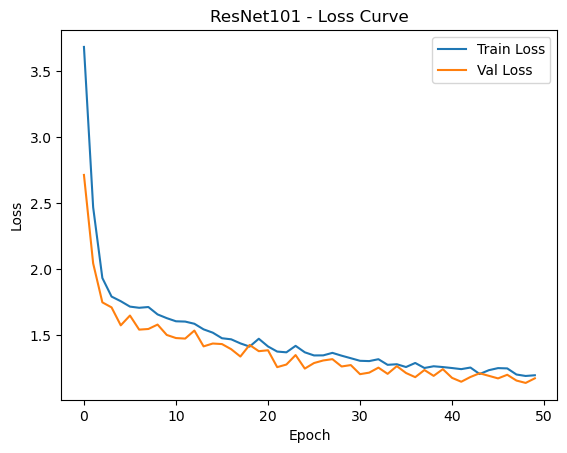

In [79]:
# Train ResNet101
resnet101_model = build_transfer_model(ResNet101)
resnet101_model = train_model(resnet101_model, "ResNet101")

Epoch 1/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.4542 - loss: 3.7906 - val_accuracy: 0.7316 - val_loss: 2.3066
Epoch 2/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.6485 - loss: 2.3075 - val_accuracy: 0.7289 - val_loss: 1.7077
Epoch 3/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.6679 - loss: 1.8212 - val_accuracy: 0.7316 - val_loss: 1.4976
Epoch 4/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.6891 - loss: 1.5968 - val_accuracy: 0.7434 - val_loss: 1.4353
Epoch 5/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.7071 - loss: 1.5195 - val_accuracy: 0.7355 - val_loss: 1.3923
Epoch 6/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.6934 - loss: 1.5126 - val_accuracy: 0.7303 - val_loss: 1.4195
Epoch 7/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.7012 - loss: 1.5081 - val_accuracy: 0.7395 - val_loss: 1.3739
Epoch 8/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.6831 - loss: 1.5329 - 

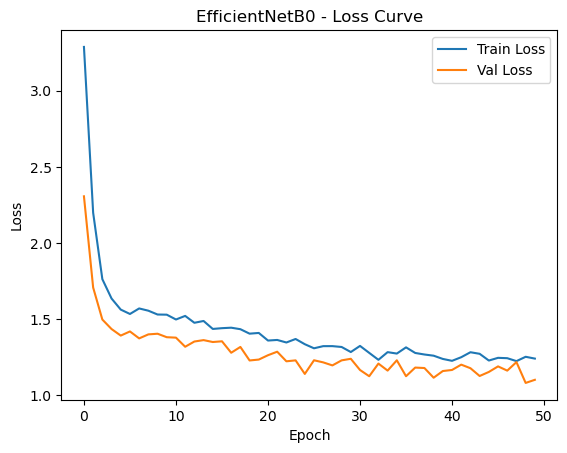

In [76]:
# Train EfficientNetB0
effnet_model = build_transfer_model(EfficientNetB0)
effnet_model = train_model(effnet_model, "EfficientNetB0")

Epoch 1/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 215s 353ms/step - accuracy: 0.3757 - loss: 3.6158 - val_accuracy: 0.5776 - val_loss: 2.2689
Epoch 2/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 235s 386ms/step - accuracy: 0.5745 - loss: 2.1772 - val_accuracy: 0.6408 - val_loss: 1.6258
Epoch 3/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 239s 392ms/step - accuracy: 0.6059 - loss: 1.7105 - val_accuracy: 0.6855 - val_loss: 1.3849
Epoch 4/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 241s 395ms/step - accuracy: 0.6000 - loss: 1.5617 - val_accuracy: 0.6868 - val_loss: 1.2846
Epoch 5/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 242s 397ms/step - accuracy: 0.6233 - loss: 1.4603 - val_accuracy: 0.6671 - val_loss: 1.2864
Epoch 6/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 243s 398ms/step - accuracy: 0.6271 - loss: 1.4259 - val_accuracy: 0.6974 - val_loss: 1.2211
Epoch 7/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 249s 410ms/step - accuracy: 0.6450 - loss: 1.3698 - val_accuracy: 0.6868 - val_loss: 1.2222
Epoch 8/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 255s 419ms/step - accuracy: 0.6324 -

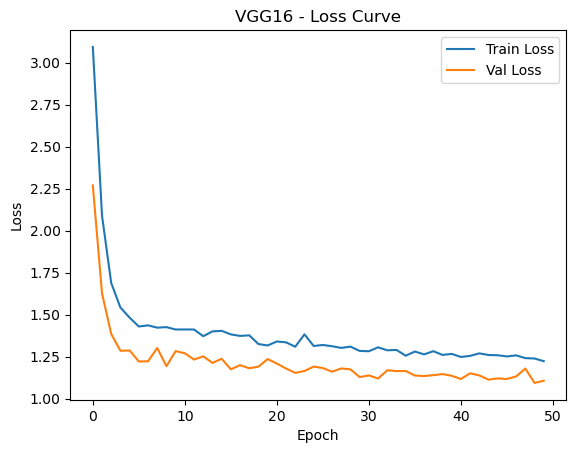

In [90]:
# Train VGG16
vgg16_model = build_transfer_model(VGG16)
vgg16_model = train_model(vgg16_model, "VGG16")

In [84]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_model_full(model, name, datasets):
    for dataset_name, (X_data, y_data) in datasets.items():
        print(f"\nEvaluating {name} on {dataset_name} set...")
        y_pred = model.predict(X_data)
        y_pred_labels = np.argmax(y_pred, axis=1)
        y_true_labels = np.argmax(y_data, axis=1)

        print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

        auc = roc_auc_score(y_data, y_pred, multi_class='ovr')
        print(f"AUC Score ({dataset_name}): {auc:.4f}")

In [85]:
val_X = []
val_y = []

# Go through all batches and collect full val set
for i in range(len(val_generator)):
    X_batch, y_batch = val_generator[i]
    val_X.extend(X_batch)
    val_y.extend(y_batch)

val_X = np.array(val_X)
val_y = np.array(val_y)

# Confirm it includes all 9 classes
print("Unique classes in val_y:", np.unique(np.argmax(val_y, axis=1)))
print("val_X shape:", val_X.shape)
print("val_y shape:", val_y.shape)

Unique classes in val_y: [0 1 2 3 4 5 6 7 8]
val_X shape: (760, 160, 160, 3)
val_y shape: (760, 9)


In [86]:
datasets = {
    "train": (X_train, y_train),
    "val": (val_X, val_y),
    "test": (X_test, y_test)
}

In [87]:
evaluate_model_full(resnet50_model, "ResNet50", datasets)


Evaluating ResNet50 on train set...
119/119 ━━━━━━━━━━━━━━━━━━━━ 57s 475ms/step
                       precision    recall  f1-score   support

          1-Cardboard       0.74      0.87      0.80       369
      2-Food Organics       0.90      0.75      0.82       329
              3-Glass       0.85      0.85      0.85       336
              4-Metal       0.72      0.93      0.81       632
5-Miscellaneous Trash       0.78      0.65      0.71       396
              6-Paper       0.79      0.78      0.79       400
            7-Plastic       0.89      0.67      0.76       736
      8-Textile Trash       0.78      0.82      0.80       254
         9-Vegetation       0.85      0.95      0.90       349

             accuracy                           0.80      3801
            macro avg       0.81      0.81      0.80      3801
         weighted avg       0.81      0.80      0.80      3801

AUC Score (train): 0.9811

Evaluating ResNet50 on val set...
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 512ms

In [88]:
evaluate_model_full(resnet101_model, "ResNet101", datasets)


Evaluating ResNet101 on train set...
119/119 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step
                       precision    recall  f1-score   support

          1-Cardboard       0.75      0.81      0.78       369
      2-Food Organics       0.87      0.81      0.84       329
              3-Glass       0.78      0.88      0.83       336
              4-Metal       0.87      0.79      0.83       632
5-Miscellaneous Trash       0.67      0.75      0.71       396
              6-Paper       0.84      0.80      0.82       400
            7-Plastic       0.78      0.77      0.77       736
      8-Textile Trash       0.85      0.69      0.76       254
         9-Vegetation       0.84      0.94      0.89       349

             accuracy                           0.80      3801
            macro avg       0.81      0.80      0.80      3801
         weighted avg       0.81      0.80      0.80      3801

AUC Score (train): 0.9811

Evaluating ResNet101 on val set...
24/24 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/st

In [89]:
evaluate_model_full(effnet_model, "EfficientNetB0", datasets)


Evaluating EfficientNetB0 on train set...
119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 180ms/step
                       precision    recall  f1-score   support

          1-Cardboard       0.75      0.82      0.79       369
      2-Food Organics       0.87      0.80      0.84       329
              3-Glass       0.71      0.93      0.81       336
              4-Metal       0.80      0.88      0.84       632
5-Miscellaneous Trash       0.81      0.64      0.72       396
              6-Paper       0.77      0.88      0.82       400
            7-Plastic       0.89      0.70      0.78       736
      8-Textile Trash       0.89      0.80      0.84       254
         9-Vegetation       0.85      0.94      0.89       349

             accuracy                           0.81      3801
            macro avg       0.82      0.82      0.81      3801
         weighted avg       0.82      0.81      0.81      3801

AUC Score (train): 0.9841

Evaluating EfficientNetB0 on val set...
24/24 ━━━━━━━━━━━━━━━━━━

In [91]:
evaluate_model_full(vgg16_model, "VGG16", datasets)


Evaluating VGG16 on train set...
119/119 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step
                       precision    recall  f1-score   support

          1-Cardboard       0.72      0.79      0.75       369
      2-Food Organics       0.74      0.90      0.81       329
              3-Glass       0.87      0.74      0.80       336
              4-Metal       0.75      0.83      0.79       632
5-Miscellaneous Trash       0.79      0.58      0.67       396
              6-Paper       0.70      0.80      0.74       400
            7-Plastic       0.79      0.74      0.76       736
      8-Textile Trash       0.80      0.65      0.71       254
         9-Vegetation       0.88      0.94      0.91       349

             accuracy                           0.77      3801
            macro avg       0.78      0.77      0.77      3801
         weighted avg       0.78      0.77      0.77      3801

AUC Score (train): 0.9720

Evaluating VGG16 on val set...
24/24 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step
     

In [92]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(model, X, y_true, dataset_name="test"):
    y_pred = model.predict(X)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_true, axis=1)

    precision = precision_score(y_true_labels, y_pred_labels, average='macro')
    recall = recall_score(y_true_labels, y_pred_labels, average='macro')
    f1 = f1_score(y_true_labels, y_pred_labels, average='macro')
    auc = roc_auc_score(y_true, y_pred, multi_class='ovr')

    return {
        "Dataset": dataset_name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4)
    }

In [93]:
results = []

# ResNet50
results.append({ "Model": "ResNet50", **get_metrics(resnet50_model, X_train, y_train, "Train") })
results.append({ "Model": "ResNet50", **get_metrics(resnet50_model, X_test, y_test, "Test") })

# ResNet101
results.append({ "Model": "ResNet101", **get_metrics(resnet101_model, X_train, y_train, "Train") })
results.append({ "Model": "ResNet101", **get_metrics(resnet101_model, X_test, y_test, "Test") })

# EfficientNetB0
results.append({ "Model": "EfficientNetB0", **get_metrics(effnet_model, X_train, y_train, "Train") })
results.append({ "Model": "EfficientNetB0", **get_metrics(effnet_model, X_test, y_test, "Test") })

# VGG16
results.append({ "Model": "VGG16", **get_metrics(vgg16_model, X_train, y_train, "Train") })
results.append({ "Model": "VGG16", **get_metrics(vgg16_model, X_test, y_test, "Test") })

119/119 ━━━━━━━━━━━━━━━━━━━━ 69s 580ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 580ms/step
119/119 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 206ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step
119/119 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step


In [94]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results = df_results[["Model", "Dataset", "Precision", "Recall", "F1-Score", "AUC"]]
display(df_results)

,Model,Dataset,Precision,Recall,F1-Score,AUC
0,ResNet50,Train,0.8112,0.8083,0.8042,0.9811
1,ResNet50,Test,0.7488,0.7411,0.7375,0.9678
2,ResNet101,Train,0.8062,0.8039,0.8027,0.9811
3,ResNet101,Test,0.7781,0.7666,0.7680,0.9710
4,EfficientNetB0,Train,0.8162,0.8213,0.8135,0.9841
5,EfficientNetB0,Test,0.7478,0.7492,0.7412,0.9693
6,VGG16,Train,0.7825,0.7731,0.7725,0.9720
7,VGG16,Test,0.7079,0.7084,0.7009,0.9553


#### Conclusion

Based on the results from the four transfer learning models — ResNet50, ResNet101, EfficientNetB0, and VGG16 — we observe the following:

 • ResNet101 achieved the highest F1-score on the test set (0.7680) and a strong AUC of 0.9710, indicating excellent generalization 
   capability. It balances accuracy and robustness across both training and test datasets.
 
 • EfficientNetB0 showed the best training performance with the highest F1-score (0.8135) and AUC (0.9841), but its drop in test performance 
   (F1-score: 0.7412) suggests moderate overfitting.
 
 • ResNet50 performed consistently with a test F1-score of 0.7375, slightly lower than ResNet101 but still reliable, showing moderate 
   generalization.
 
 • VGG16 underperformed across all metrics, with the lowest test F1-score (0.7009) and AUC (0.9553).

ResNet101 is the most effective model for this multi-class waste classification task, demonstrating the best balance between training accuracy and test generalization. While EfficientNetB0 is promising in terms of learning capacity, its overfitting makes it less reliable than ResNet101 for unseen data.